## 📊**Capstone Project Module 3**
## Retail Point of Sales (POS) Analysis
### Business Case: Data Quality Analysis for Promotional Leakage and POS Operational Issues at Alfamart

#### Table of Contents

1. Business Understanding
2. Data Preparation
3. Exploratory Data Analysis
4. Business Insights & Recommendations
5. Conclusion

## 📖 **Business Understanding**

*This section provides an overview of the business context, key business problems, and project objectives. Understanding these aspects is essential before performing data preparation and analysis.*

#### Background

Alfamart processes millions of Point of Sale (POS) transactions every day across thousands of stores in Indonesia. Due to the large transaction volume, data quality issues such as synchronization delays, cashier input errors, inconsistent payment records, and abnormal transactions may occur. In addition, promotional programs (JSM) are vulnerable to misuse by bulk buyers, reducing promotional effectiveness and profit margins. Therefore, this analysis aims to identify data quality issues and business anomalies to support more accurate reporting and better business decision-making.

#### Problem Statement

The company faces several operational and data quality issues that may reduce promotional effectiveness, inventory accuracy, and reporting reliability. This project aims to answer the following business questions:

| Business Problem | 
| --- |
|1. Which stores have the highest volume of JSM promotional transactions dominated by only a small number of members, (indicating potential bulk buyers or resellers)?|
|2. Which FMCG product categories experience the highest number of void or cancelled transactions at the cashier?|
|3. How inconsistent are the payment method records (e.g., Cash, Tunai, E-Wallet) across different stores?|
|4. What percentage of transactions have missing member IDs, preventing the CRM team from tracking Customer Lifetime Value (CLV)?|
|5. Are there any transactions recorded before the official store opening date, (indicating logical errors in the POS system)?|
|6. Are there extreme or invalid quantity (QTY) values, such as unusually large purchases or negative quantities, that may indicate scanning errors or data entry issues?|

#### Business Goals

This project aims to improve the quality of POS transaction data and support better business decision-making by achieving the following objectives:

| Business Goal | Description |
| --- | --- |
| **Promo Protection** | Identify unusual purchasing patterns during JSM promotions and support the development of rules to limit excessive promotional purchases by individual members. |
| **Cashier SOP Evaluation** | Detect abnormal scanning activities, such as negative or unusually high quantity (QTY) values, to evaluate cashier performance and support operational training. |
| **Master Data Management** | Standardize payment method records and product categories to improve data consistency and ensure accurate financial and operational reporting. |
| **Fraud & System Error Detection** | Identify logical transaction errors, such as transactions recorded before a store official opening date, to improve data reliability and maintain accurate sales history. |

## ⚙️ **Data Preparation**

*Before performing the analysis, the datasets need to be prepared to ensure they are complete, consistent, and suitable for analysis. This section introduces the datasets, loads them into Python, explores their structure, and performs the necessary data cleaning process.*

#### Dataset Overview

This project uses three related datasets representing different aspects of Alfamart's Point of Sale (POS) operations.

Together, these datasets provide information about store profiles, product master data, and transaction records that will be used to answer the business questions.

#### Dataset Description

The analysis is based on three datasets:

| Dataset | Description |
| --- | --- |
| **alfa_stores.csv** | Store information including store name, city, and official opening date. |
| **alfa_products.csv** | Product master data including product name, category, and unit price. |
| **alfa_pos_transactions.csv** | Point of Sale (POS) transaction records including purchased products, quantity, payment method, and transaction time. |

The transaction dataset is the primary dataset and contains approximately **300,000 transaction records**.

#### Dataset Dictionary

The following tables describe the variables contained in each dataset and their role in the analysis.

#### 1. Store Dataset — `alfa_stores.csv`

| Column | Description |
| --- | --- |
| **store_id** | Unique identifier for each Alfamart store. |
| **store_name** | Name of the store. |
| **city** | City where the store is located. |
| **open_date** | Official date when the store started operating. |

#### 2. Product Dataset — `alfa_products.csv`

| Column | Description |
| --- | --- |
| **sku_id** | Unique identifier for each product (SKU). |
| **product_name** | Name of the product. |
| **category** | Product category, such as Food, Beverage, Personal Care, etc. |
| **unit_price** | Normal selling price per unit. |

#### 3. Transaction Dataset — `alfa_pos_transactions.csv`

| Column | Description |
| --- | --- |
| **receipt_id** | Unique receipt identifier. |
| **store_id** | Unique identifier for each Alfamart store. |
| **sku_id** | Unique identifier for each product (SKU). |
| **member_id** | Alfamart/Pontam member identifier. |
| **trx_time** | Date and time when the transaction was recorded at the cashier. |
| **payment_method** | Payment method used for the transaction. |
| **qty** | Quantity of products purchased. |
| **total_price** | Total transaction value, calculated from quantity and unit price. |

#### Import Required Libraries

The following libraries are used for data manipulation, visualization, and statistical analysis.

In [77]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

#### Load Datasets

The three CSV files are loaded into separate Pandas DataFrames for further exploration and analysis.

In [78]:
stores = pd.read_csv('alfa_stores.csv')
products = pd.read_csv('alfa_products.csv')
transactions = pd.read_csv('alfa_pos_transactions.csv')

#### Data Understanding

Before performing data cleaning, the structure and quality of each dataset are examined. This includes checking the number of rows and columns, data types, missing values, duplicate records, and basic statistical information.

In [79]:
print("Stores       :", stores.shape)
print("Products     :", products.shape)
print("Transactions :", transactions.shape)

Stores       : (1000, 4)
Products     : (500, 4)
Transactions : (300000, 8)


- The store dataset contains 1,000 records and 4 columns.
- The product dataset contains 500 records and 4 columns.
- The transaction dataset contains 300,000 records and 8 columns.

The transaction dataset is the largest dataset and will be the primary source for answering most of the business questions.

#### Preview the Datasets

The first few rows of each dataset are displayed to verify the data structure and identify the variables available for analysis.

In [80]:
stores.head()

,store_id,store_name,city,open_date
0,SAT-0001,Alfamart Sudirman 0,Depok,2022-05-08
1,SAT-0002,Alfamart Diponegoro 1,Surabaya,2022-09-16
2,SAT-0003,Alfamart Melati 2,Depok,2022-05-24
3,SAT-0004,Alfamart Sudirman 3,Tangerang,2022-05-01
4,SAT-0005,Alfamart Melati 4,Bogor,2021-03-27


In [81]:
products.head()

,sku_id,product_name,category,unit_price
0,SKU000001,Air Mineral Aqua,Beverage,12100.0
1,SKU000002,Indm Grg,Food & Staples,39000.0
2,SKU000003,Bimoli Pouch 2000ml,Food & Staples,12900.0
3,SKU000004,Air Mineral Aqua,Beverage,27800.0
4,SKU000005,Rokok Sampoerna Mild,Cigarettes,13800.0


In [82]:
transactions.head()

,receipt_id,store_id,sku_id,member_id,trx_time,payment_method,qty,total_price
0,RCP00000001,SAT-0142,SKU000180,MEM-11247,2022-12-24 21:00:00,BCA Debit,1,33500.0
1,RCP00000002,SAT-0294,SKU000115,MEM-32305,2022-10-25 14:00:00,Cash,2,62200.0
2,RCP00000003,SAT-0623,SKU000132,MEM-08155,2022-12-02 08:00:00,Tunai,3,85500.0
3,RCP00000004,SAT-0386,SKU000262,MEM-12656,2024-07-28 09:00:00,CASH,12,314400.0
4,RCP00000005,SAT-0665,SKU000437,MEM-44669,2023-07-14 12:00:00,ShopeePay,1,16700.0


#### Check Data Types and Missing Values

In [83]:
stores.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   store_id    1000 non-null   str  
 1   store_name  1000 non-null   str  
 2   city        1000 non-null   str  
 3   open_date   1000 non-null   str  
dtypes: str(4)
memory usage: 31.4 KB


In [84]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku_id        500 non-null    str    
 1   product_name  500 non-null    str    
 2   category      500 non-null    str    
 3   unit_price    500 non-null    float64
dtypes: float64(1), str(3)
memory usage: 15.8 KB


In [85]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   receipt_id      300000 non-null  str    
 1   store_id        300000 non-null  str    
 2   sku_id          300000 non-null  str    
 3   member_id       180000 non-null  str    
 4   trx_time        300000 non-null  str    
 5   payment_method  300000 non-null  str    
 6   qty             300000 non-null  int64  
 7   total_price     300000 non-null  float64
dtypes: float64(1), int64(1), str(6)
memory usage: 18.3 MB


#### *Key Findings*

The result shows that:

- The `member_id` column contains only 180,000 non-null values and **120,000 missing values**.
- The `open_date` and `trx_time` columns are currently stored as strings and may need to be converted into datetime format.

#### Missing Value Analysis

Missing values are checked to identify incomplete records that may affect the analysis.

Particular attention is given to `member_id` because missing member IDs may limit customer-level analysis and CRM tracking.

In [86]:
missing_values = transactions.isnull().sum()

missing_values

receipt_id             0
store_id               0
sku_id                 0
member_id         120000
trx_time               0
payment_method         0
qty                    0
total_price            0
dtype: int64

To better understand the impact of these missing values, we next calculate the missing percentage for each column.

In [87]:
missing_percentage = (transactions.isnull().sum() / len(transactions) * 100)

missing_summary = pd.DataFrame({"missing_count": missing_values,"missing_percentage": missing_percentage})

missing_summary

,missing_count,missing_percentage
receipt_id,0,0.0
store_id,0,0.0
sku_id,0,0.0
member_id,120000,40.0
trx_time,0,0.0
payment_method,0,0.0
qty,0,0.0
total_price,0,0.0


#### *Key Findings*

The missing value analysis shows that most transaction fields are complete.

- The `member_id` column contains **120,000 missing values**, representing **40% of all transaction records**.
- All other transaction fields have no missing values.
- Missing `member_id` values may limit the ability to associate transactions with registered members and perform customer-level analysis.
- Therefore, `member_id` completeness will be considered as an important data quality indicator in this project.

#### Duplicate Check

Duplicate records are checked to ensure that the same transaction is not recorded more than once.

Duplicate transactions may cause overcounting when calculating transaction volume, quantity, and sales value.

In [88]:
print("Duplicate stores      :", stores.duplicated().sum())
print("Duplicate products    :", products.duplicated().sum())
print("Duplicate transactions:", transactions.duplicated().sum())

Duplicate stores      : 0
Duplicate products    : 0
Duplicate transactions: 0


No duplicate key issue was identified at this stage. The datasets are structurally suitable for further data preparation and analysis.

#### Date and Time Conversion

The `open_date` and `trx_time` columns are currently stored as strings.

They are converted into datetime format to support time-based analysis, particularly the identification of transactions that occurred before the official store opening date.

In [89]:
stores["open_date"] = pd.to_datetime(stores["open_date"])

transactions["trx_time"] = pd.to_datetime(transactions["trx_time"])

print("open_date:", stores["open_date"].dtype)
print("trx_time :", transactions["trx_time"].dtype)

open_date: datetime64[us]
trx_time : datetime64[us]


#### Payment Method Consistency

Payment method values are reviewed to identify inconsistent naming conventions.

Different labels may represent the same payment method, such as `Cash`, `CASH`, or `Tunai`. Such inconsistencies can affect grouping, reporting, and financial analysis.

In [90]:
transactions["payment_method"].value_counts()

payment_method
Cash         74835
CASH         45169
Gopay        30211
BCA Debit    30132
Tunai        30088
ShopeePay    29929
qris         14982
QRIS         14958
OVO          14935
debit bca    14761
Name: count, dtype: int64

In [91]:
payment_mapping = {
    "Cash": "Cash",
    "CASH": "Cash",
    "Tunai": "Cash",
    "BCA Debit": "BCA Debit",
    "debit bca": "BCA Debit",
    "qris": "QRIS",
    "QRIS": "QRIS"
}

transactions["payment_method"] = transactions["payment_method"].replace(payment_mapping)

After standardization, the payment methods were grouped into 6 consistent categories for further analysis.

In [92]:
transactions["payment_method"].value_counts()

payment_method
Cash         150092
BCA Debit     44893
Gopay         30211
QRIS          29940
ShopeePay     29929
OVO           14935
Name: count, dtype: int64

In [93]:
print("Unique payment methods after cleaning:", transactions["payment_method"].unique())

Unique payment methods after cleaning: <StringArray>
['BCA Debit', 'Cash', 'ShopeePay', 'QRIS', 'OVO', 'Gopay']
Length: 6, dtype: str


In [94]:
print("Number of payment method categories:",transactions["payment_method"].nunique())

Number of payment method categories: 6


The total number of transactions should remains 300,000 before and after payment method cleaning, meaning no transaction records were removed.

In [95]:
before_payment_cleaning = len(transactions)

print("Total transactions:", before_payment_cleaning)

Total transactions: 300000


In [96]:
after_payment_cleaning = len(transactions)

print("Total transactions:", after_payment_cleaning)

Total transactions: 300000


#### *Key Findings*

The payment method data contained inconsistent labels for several payment types.
a
The main inconsistencies were:

- `Cash`, `CASH`, and `Tunai` were standardized into `Cash`.
- `BCA Debit` and `debit bca` were standardized into `BCA Debit`.
- `qris` and `QRIS` were standardized into `QRIS`.

After standardization, the payment method categories became more consistent and can be used for reliable aggregation and comparison across stores.

#### Quantity Validation

The `qty` column is examined for invalid and extreme values.

Negative quantities may indicate data entry or system issues, while extremely high quantities may represent abnormal transaction and require further investigation.

In [97]:
transactions["qty"].describe()

count    300000.000000
mean         30.957860
std         500.924037
min          -5.000000
25%           1.000000
50%           2.000000
75%           3.000000
max        9999.000000
Name: qty, dtype: float64

The `qty` data contains negative values down to -5 and extreme values up to 9,999, indicating potential transaction or data-entry anomalies that require further investigation.

In [98]:
negative_qty = (transactions["qty"] < 0).sum()

print("Negative quantity:", negative_qty)

Negative quantity: 1483


In [99]:
transactions.nlargest(10, "qty")[["receipt_id", "store_id", "sku_id", "member_id", "qty", "total_price"]]

,receipt_id,store_id,sku_id,member_id,qty,total_price
725,RCP00000726,SAT-0016,SKU000076,MEM-24871,9999,42995700.0
1326,RCP00001327,SAT-0446,SKU000254,NaN,9999,154984500.0
1346,RCP00001347,SAT-0650,SKU000244,NaN,9999,214978500.0
1544,RCP00001545,SAT-0881,SKU000203,NaN,9999,388961100.0
1764,RCP00001765,SAT-0927,SKU000457,MEM-45813,9999,117988200.0
1781,RCP00001782,SAT-0084,SKU000085,MEM-09001,9999,134986500.0
1964,RCP00001965,SAT-0097,SKU000475,NaN,9999,134986500.0
2496,RCP00002497,SAT-0934,SKU000139,NaN,9999,363963600.0
2793,RCP00002794,SAT-0144,SKU000007,MEM-40013,9999,295970400.0
3173,RCP00003174,SAT-0306,SKU000038,NaN,9999,240975900.0


#### *Key Findings*

The quantity validation identified several potential data anomalies:

- A total of **1,483 transactions have negative quantity values**, which are not expected for normal sales transactions and may indicate voids, returns, or data entry/system errors.
- The maximum quantity recorded is **9,999 units**, which is unusually high for a typical retail transaction.
- Several transactions with a quantity of 9,999 also have extremely high total prices, indicating potential scanning or data entry anomalies.

These findings indicate that the `qty` field requires further investigation. The anomalous records will not be removed at this stage because they may represent different business scenarios such as returns or transaction adjustments. Further analysis will be performed in the Exploratory Data Analysis (EDA) section to determine their business impact.

#### Logical Error Validation

A transaction should not occur before the official opening date of the store.


The **transactions** data is combined with the **stores** master using `store_id` as the key to validate whether the recorded `trx_time` is consistent with the store's official `open_date`.

In [100]:
transactions = transactions.merge(stores[["store_id", "open_date"]],on="store_id",how="left")

The transactions time `trx_time` is compared with the stores `open_date` to identify potential logical errors in the POS records.

In [101]:
transactions["before_opening"] = (transactions["trx_time"] < transactions["open_date"])

The number of transactions marked as `True` is then counted to identify potential logical errors in the POS records.

In [102]:
transactions["before_opening"].value_counts()

before_opening
False    291000
True       9000
Name: count, dtype: int64

### *Key Findings*

- **9,000 transactions** were recorded before the stores official opening dates.
- This indicates **potential logical errors in the POS transaction records** and should be investigated further.

In [103]:
transactions[transactions["before_opening"]].head()

,receipt_id,store_id,sku_id,member_id,trx_time,payment_method,qty,total_price,open_date,before_opening
20,RCP00000021,SAT-0115,SKU000119,MEM-10142,2022-02-18 12:00:00,BCA Debit,1,35700.0,2022-05-07,True
58,RCP00000059,SAT-0609,SKU000385,NaN,2022-07-20 05:00:00,QRIS,2,60400.0,2022-09-14,True
62,RCP00000063,SAT-0565,SKU000131,NaN,2021-12-07 15:00:00,Cash,5,208500.0,2022-02-22,True
79,RCP00000080,SAT-0957,SKU000273,MEM-10162,2021-11-17 14:00:00,BCA Debit,24,957600.0,2022-02-04,True
161,RCP00000162,SAT-0160,SKU000399,NaN,2021-12-18 14:00:00,Cash,1,11400.0,2022-01-01,True


### **Data Preparation Summary**

The data preparation process identified four main data quality issues for further analysis:

- **Missing Member ID:** 120,000 transactions (40%) have missing `member_id`.
- **Quantity Anomalies:** 1,483 transactions have negative quantities, with a maximum quantity of 9,999 units.
- **Payment Method:** Inconsistent payment labels were standardized into consistent categories.
- **Logical Errors:** 9,000 transactions occurred before the stores' official opening dates.

These issues are further investigated in the EDA based on the defined business problems and goals.

## 🔎 **Exploratory Data Analysis**

This section explores the transaction data to identify patterns and issues related to the defined business problems.


#### JSM Transaction Analysis

JSM transactions run from Friday to Sunday. This analysis identifies stores with high JSM transaction volume and a relatively small number of unique members, which may indicate unusual promotional purchasing.

In [104]:
transactions["is_jsm"] = (transactions["trx_time"].dt.dayofweek.isin([4, 5, 6]))

In [105]:
jsm_transactions = transactions[
    (transactions["is_jsm"]) &
    (transactions["member_id"].notna())
].copy()

The JSM transactions are grouped by store to compare the transaction volume with the number of unique members involved.


In [113]:
jsm_store = (
    jsm_transactions
    .groupby("store_id")
    .agg(
        jsm_transactions=("receipt_id", "count"),
        unique_members=("member_id", "nunique")
    )
    .sort_values("jsm_transactions", ascending=False)
)

jsm_store.head(10)

,jsm_transactions,unique_members
store_id,,
SAT-0756,109,109
SAT-0416,106,106
SAT-0536,104,104
SAT-0019,103,103
SAT-0058,101,101
SAT-0073,100,100
SAT-0143,99,99
SAT-0113,99,99
SAT-0529,99,99


The stores with the highest JSM transaction volumes also have a similar number of unique members, indicating that transactions are not concentrated among a small number of identified members.

### JSM Member Data Limitation

Before evaluating member-level purchasing patterns, the availability of `member_id` is checked because missing member IDs may limit the ability to identify transactions associated with individual members.

In [107]:
jsm_member_status = transactions[
    transactions["is_jsm"]
]["member_id"].isna().value_counts()

jsm_member_status

member_id
False    76717
True     51712
Name: count, dtype: int64

In [108]:
jsm_member_percentage = (
    transactions[transactions["is_jsm"]]["member_id"]
    .isna()
    .mean() * 100
)

print("JSM transactions without member_id:", jsm_member_percentage, "%")

JSM transactions without member_id: 40.26504917113736 %


The analysis shows that **40.27% of JSM transactions do not have a `member_id`**, so member-level results should be interpreted with caution.

#### JSM Member vs Non-Member

JSM transactions are separated into member and non-member transactions to assess whether unusual purchasing patterns may also occur among transactions without member identification.

In [109]:
jsm_all = transactions[
    transactions["is_jsm"]
].copy()

jsm_all["member_status"] = (
    jsm_all["member_id"]
    .notna()
    .map({
        True: "Member",
        False: "Non-Member"
    })
)

In [110]:
jsm_member_vs_nonmember = (
    jsm_all
    .groupby("member_status")
    .agg(
        transactions=("receipt_id", "count"),
        total_qty=("qty", "sum"),
        max_qty=("qty", "max")
    )
)

jsm_member_vs_nonmember

,transactions,total_qty,max_qty
member_status,,,
Member,76717,2273431,9999
Non-Member,51712,1736523,9999


The results show that unusually large quantities occur in both member and non-member transactions. However, non-member transactions cannot be linked across purchases because no member_id is available.

In [111]:
nonmember_bulk = (
    jsm_all[
        (jsm_all["member_status"] == "Non-Member") &
        (jsm_all["qty"] >= 999)
    ]
    .sort_values("qty", ascending=False)
)

nonmember_bulk[
    ["receipt_id", "store_id", "sku_id", "qty"]
].head(20)

,receipt_id,store_id,sku_id,qty
6383,RCP00006384,SAT-0235,SKU000270,9999
7270,RCP00007271,SAT-0192,SKU000404,9999
8653,RCP00008654,SAT-0921,SKU000212,9999
286874,RCP00286875,SAT-0421,SKU000116,9999
289944,RCP00289945,SAT-0058,SKU000407,9999
296136,RCP00296137,SAT-0335,SKU000259,9999
240953,RCP00240954,SAT-0414,SKU000493,9999
241592,RCP00241593,SAT-0759,SKU000162,9999
243570,RCP00243571,SAT-0769,SKU000022,9999
244646,RCP00244647,SAT-0914,SKU000152,9999


These transactions contain quantities of up to 9,999 units. However, without member identification, the analysis cannot determine whether they represent repeat bulk buyers, resellers, or data-entry/scanning issues.

#### *Key Finding*

No clear concentration of JSM transactions among a small number of identified members was observed.

However, **40.27% of JSM transactions have no member_id**, limiting the ability to identify potential bulk buyers or resellers among non-member transactions.

#### FMCG Abnormal Transaction Analysis

Negative quantity transactions are analyzed by FMCG category as an indicator of potentially abnormal or cancelled transactions.

In [114]:
fmcg_data = transactions.merge(
    products[["sku_id", "category"]],
    on="sku_id",
    how="left"
)

fmcg_negative_qty = (
    fmcg_data[fmcg_data["qty"] < 0]
    .groupby("category")["receipt_id"]
    .count()
    .sort_values(ascending=False)
)

fmcg_negative_qty

category
Food & Staples    601
Beverage          298
Personal Care     296
Cigarettes        288
Name: receipt_id, dtype: int64

The analysis compares negative quantity transactions across FMCG categories to identify which categories show the highest level of abnormal transaction activity.

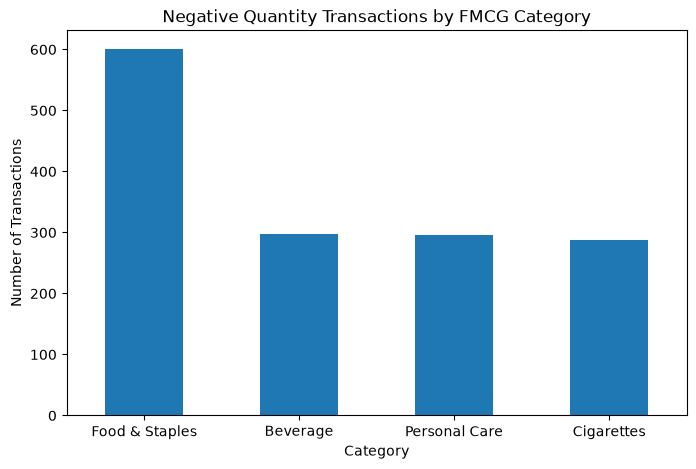

In [ ]:
plt.figure(figsize=(8, 5))

fmcg_negative_qty.plot(kind="bar")

plt.title("Negative Quantity Transactions by FMCG Category")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.show()

#### *Key Finding*

**Food & Staples has the highest number of negative quantity transactions**, followed by Beverage, Personal Care, and Cigarettes.

As the dataset does not contain a dedicated void or cancellation status, negative quantity transactions are used as an indicator of potentially abnormal or cancelled transactions. **Food & Staples therefore requires the most attention for further review of cashier transaction procedures.**

#### Payment Method Consistency

Payment method records are checked to identify inconsistent labels across transactions and stores.

In [ ]:
payment_raw = pd.read_csv("alfa_pos_transactions.csv")

In [ ]:
payment_raw["payment_method"].value_counts()

payment_method
Cash         74835
CASH         45169
Gopay        30211
BCA Debit    30132
Tunai        30088
ShopeePay    29929
qris         14982
QRIS         14958
OVO          14935
debit bca    14761
Name: count, dtype: int64

In [ ]:
payment_mapping = {
    "Cash": "Cash",
    "CASH": "Cash",
    "Tunai": "Cash",
    "BCA Debit": "BCA Debit",
    "debit bca": "BCA Debit",
    "qris": "QRIS",
    "QRIS": "QRIS"
}

payment_raw["payment_method_standard"] = (
    payment_raw["payment_method"].replace(payment_mapping)
)

In [ ]:
payment_raw["is_inconsistent"] = (payment_raw["payment_method"]!= payment_raw["payment_method_standard"])

In [ ]:
inconsistent_count = payment_raw["is_inconsistent"].sum()

inconsistent_percentage = (inconsistent_count / len(payment_raw) * 100)

print("Inconsistent records:", inconsistent_count)
print("Inconsistency rate:", inconsistent_percentage, "%")

Inconsistent records: 105000
Inconsistency rate: 35.0 %


**35% of transactions have inconsistent payment method labels**, highlighting the need for payment method standardization to support more reliable reporting.


In [ ]:
store_payment = (payment_raw.groupby("store_id")["is_inconsistent"].agg(["sum", "mean"]))

store_payment["percentage"] = store_payment["mean"] * 100

store_payment = store_payment.sort_values("percentage",ascending=False)

store_payment.head(10)

,sum,mean,percentage
store_id,,,
SAT-0667,125,0.437063,43.706294
SAT-0087,132,0.425806,42.580645
SAT-0084,136,0.423676,42.367601
SAT-0769,119,0.420495,42.049470
SAT-0914,124,0.420339,42.033898
SAT-0323,131,0.419872,41.987179
SAT-0801,121,0.418685,41.868512
SAT-0757,121,0.418685,41.868512
SAT-0347,118,0.416961,41.696113


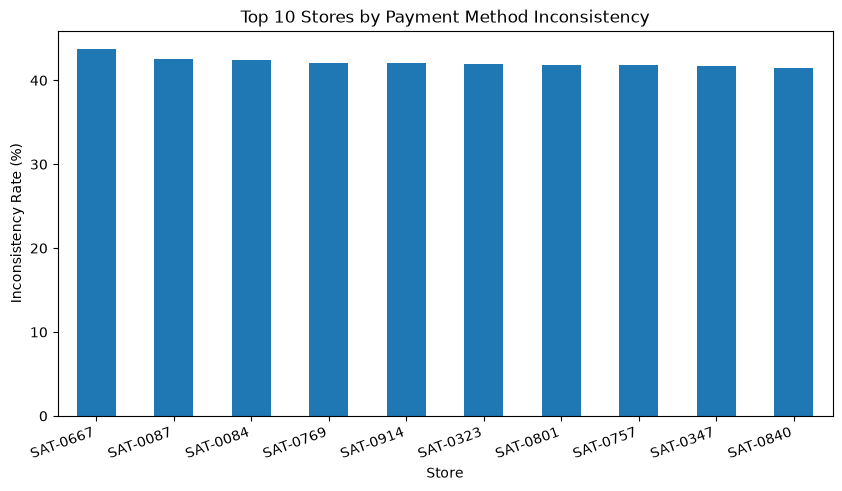

In [ ]:
plt.figure(figsize=(10, 5))

store_payment["percentage"].head(10).plot(kind="bar")

plt.title("Top 10 Stores by Payment Method Inconsistency")
plt.xlabel("Store")
plt.ylabel("Inconsistency Rate (%)")
plt.xticks(rotation=20, ha="right")

plt.show()

- Payment method inconsistencies are common across stores, with the top 10 stores showing rates of around **41%–43%**. This highlights the need for payment method standardization to support more reliable reporting.


#### *Key Finding*

The analysis shows that **105,000 transactions (35%) have inconsistent payment method labels**, and the top 10 stores have inconsistency rates of around **41%–44%**. This indicates a widespread data consistency issue and supports the need for **payment method standardization** to improve reporting accuracy. 

**Indicating a need for standardized payment classifications.**

#### Missing Member ID Analysis

The availability of `member_id` is analyzed to determine how many transactions can be linked to registered members.

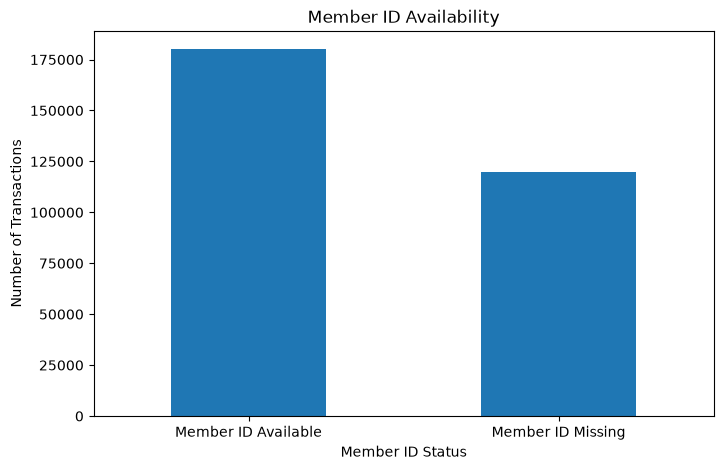

In [ ]:
member_status = transactions["member_id"].isna().value_counts()

member_status.index = ["Member ID Available", "Member ID Missing"]

member_status.plot(kind="bar",figsize=(8, 5))

plt.title("Member ID Availability")
plt.xlabel("Member ID Status")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.show()

- The chart shows that 120,000 transactions (40%) do not have a `member_id`, which may limit customer-level analysis.

#### Quantity Analysis

Transaction quantities are analyzed to identify negative and unusually high values that may indicate abnormal scanning or data entry activities.

#### Negative Quantity 

Negative quantity values are checked to identify transactions that may represent abnormal scanning or transaction-entry activity.

In [ ]:
negative_qty = (transactions["qty"] < 0).sum()

print("Negative quantity:", negative_qty)

Negative quantity: 1483


#### Extreme Quantity 

Unusually high quantity values are reviewed to identify potential abnormal scanning or data entry records.

In [ ]:
extreme_qty = transactions["qty"].isin([999, 9999]).sum()

print("Extreme quantity:", extreme_qty)

Extreme quantity: 1517


#### Extreme Quantity Analysis

Transaction quantities are reviewed to identify negative and unusually high values that may indicate scanning, void, or data entry issues.

In [ ]:
transactions[
    transactions["qty"].isin([-5, -1, 999, 9999])
][
    ["receipt_id", "store_id", "sku_id", "qty", "total_price"]
].head(10)

,receipt_id,store_id,sku_id,qty,total_price
23,RCP00000024,SAT-0482,SKU000370,-5,-218500.0
38,RCP00000039,SAT-0758,SKU000465,999,29370600.0
294,RCP00000295,SAT-0897,SKU000203,999,38861100.0
303,RCP00000304,SAT-0849,SKU000206,999,32267700.0
398,RCP00000399,SAT-0743,SKU000030,999,37262700.0
558,RCP00000559,SAT-0795,SKU000046,999,30369600.0
725,RCP00000726,SAT-0016,SKU000076,9999,42995700.0
762,RCP00000763,SAT-0824,SKU000220,-1,-30400.0
840,RCP00000841,SAT-0630,SKU000243,-5,-174000.0
884,RCP00000885,SAT-0862,SKU000209,-1,-27100.0


The analysis identified both negative and extreme quantity values. These records are reviewed further to determine whether they represent valid business transactions or potential scanning and data entry issues.

#### *Key Finding*

**1,483 transactions have negative quantities, while 1,517 transactions contain extreme quantities of 999 or 9,999 units.** These abnormal values may indicate scanning or data entry issues and should be reviewed as part of the **Cashier SOP Evaluation**.



### **EDA Summary**

The exploratory analysis highlights the main findings related to the defined business goals:

- **Promo Protection:** No clear concentration of JSM transactions among a small number of identified members was observed. However, **40.27% of JSM transactions have no `member_id`**, limiting the ability to fully identify potential excessive promotional purchases.

- **Cashier SOP Evaluation:** **1,483 transactions have negative quantities** and **1,517 transactions contain extreme quantities of 999 or 9,999 units**. **Food & Staples** has the highest number of negative quantity transactions and may require further review of cashier transaction procedures.

- **Master Data Management:** **105,000 transactions (35%) have inconsistent payment method labels**, with the highest store-level inconsistency rates around **41%–44%**, indicating a need for payment method standardization.

- **Fraud & System Error Detection:** **9,000 transactions were recorded before the stores official opening dates**, indicating potential logical errors in POS transaction records.

## 💡 **Business Insights & Recommendations**

The analysis identifies key findings and actionable recommendations aligned with the four business goals.

#### 🛡️ Promo Protection

|**Insight:**|No clear concentration of JSM transactions among a small number of identified members was observed. However, **40.27% of JSM transactions have no `member_id`**, limiting the ability to identify potential bulk buyers or resellers.|
| --- | ---|
|**Recommendation:**|Require member identification for JSM promotional purchases. Non-members can register directly at the POS before receiving the promotional price, allowing JSM purchases to be tracked and limited per customer.|
| --- |Implement a JSM purchase-limit alert in the POS when promotional quantity exceeds the defined limit in real time and blocks or changes excess units to the normal price.|

    🛡️ 1. JSM PROMO

    Customer: Non-Member
    Product: Aqua 600ml
    Quantity: 4

    ⚠️ JSM promotion requires member identification.

    [Register Member]
    [Continue at Normal Price]

    🛡️ 2. JSM PROMO LIMIT

    Customer: Member
    Member ID: MEM-12345
    Product: Aqua 600ml

    Current Quantity: 6
    Promo Limit: 5

    ⚠️ Promotional limit exceeded.

    [Apply Promo to 5]
    [Continue at Normal Price]

#### 🧾 Cashier SOP Evaluation

|**Insight:**|**1,483 transactions have negative quantities** and **1,517 transactions contain extreme quantities of 999 or 9,999 units**. Food & Staples has the highest number of negative quantity transactions.|
| --- | --- |
|**Recommendation:**|1. Use the findings to provide training needs and improve cashier scanning and transaction-entry procedures.|
| --- |2. Add a POS quantity warning that requires cashier confirmation and a reason code for negative or unusually high quantities.|

    ⚠️ 2a. UNUSUAL QUANTITY

    Entered quantity: 9,999 units
    Please confirm the quantity.

    [Re-scan]   [Confirm]

    ⚠️ 2b. NEGATIVE QUANTITY

    Quantity: -1

    Reason:
    ○ Void
    ○ Return
    ○ Adjustment

    [Submit]

#### 💳 Master Data Management

|**Insight:**|**105,000 transactions (35%) have inconsistent payment method labels**, with the highest store-level inconsistency rates around **41%–44%**.|
| --- | --- |
|**Recommendation:**|Apply standardized payment method labels across all stores, replace free-text payment entry with **a standardized POS dropdown** to prevent inconsistent payment labels in the POS system.|


    💳 PAYMENT METHOD

    Select payment method:

    ┌──────────────────────┐
    │ ▼ Cash               │
    └──────────────────────┘

    Cash
    BCA Debit
    QRIS
    Gopay
    ShopeePay

    [Confirm Payment]

#### 🚨 Fraud & System Error Detection

|**Insight:**|**9,000 transactions were recorded before the stores official opening dates**, indicating potential logical errors in POS records.
| --- | --- |
|**Recommendation:**|Add a POS date-validation rule that blocks transactions recorded before the store's official opening date.|

    🚫 TRANSACTION BLOCKED

    Store opening date: 15 Jul 2023
    Transaction date: 10 Jul 2023

    Transaction cannot be processed before store opening.

    [OK]

These actions can help protect JSM promotions, improve cashier procedures, strengthen POS data consistency, and reduce logical errors in transaction records.

## 🎯 Conclusion

The analysis highlights four key areas for business improvement:

- **Promo Protection:** Member-level monitoring is limited by incomplete `member_id` data. JSM promotions should therefore require customer identification and apply purchase-limit rules to prevent excessive promotional purchases.
- **Cashier SOP Evaluation:** Abnormal quantity patterns highlight the need for stronger POS quantity controls and targeted cashier training.
- **Master Data Management:** Payment method input should be standardized at the POS to improve data consistency and reporting reliability.
- **Fraud & System Error Detection:** Transaction-date validation should prevent records from being created before a store officially opens.

Overall, the recommended improvements focus on strengthening **promotion control, cashier performance, POS data consistency, and transaction validation**.